# Predicting Irrigation Need | Classification

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

# ML Models
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.naive_bayes import BernoulliNB
from sklearn.naive_bayes import MultinomialNB
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier


# Preprocessing
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score

# Metrics
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_auc_score, roc_curve
)

In [2]:
train = pd.read_csv("train.csv")
test = pd.read_csv("test.csv")

In [3]:
print(train.shape)
print(test.shape)

(630000, 21)
(270000, 20)


In [4]:
train.head()

,id,Soil_Type,Soil_pH,Soil_Moisture,Organic_Carbon,Electrical_Conductivity,Temperature_C,Humidity,Rainfall_mm,Sunlight_Hours,...,Crop_Type,Crop_Growth_Stage,Season,Irrigation_Type,Water_Source,Field_Area_hectare,Mulching_Used,Previous_Irrigation_mm,Region,Irrigation_Need
0,0,Loamy,4.92,32.58,1.01,3.05,15.01,50.61,725.99,5.90,...,Sugarcane,Sowing,Zaid,Drip,Rainwater,0.82,No,112.16,East,Low
1,1,Clay,7.08,56.61,0.44,2.00,22.92,67.86,985.66,6.98,...,Wheat,Vegetative,Kharif,Rainfed,River,5.27,Yes,47.16,South,Low
2,2,Clay,5.69,27.71,0.81,2.83,26.97,92.22,2201.70,6.05,...,Rice,Vegetative,Kharif,Sprinkler,Reservoir,8.24,Yes,110.38,North,Low
3,3,Sandy,5.65,13.32,1.33,0.87,13.32,61.57,1357.33,9.12,...,Wheat,Flowering,Kharif,Canal,River,8.32,Yes,53.85,South,Medium
4,4,Clay,7.96,59.14,0.38,0.96,20.22,91.11,1538.20,6.95,...,Wheat,Sowing,Rabi,Canal,River,7.37,No,93.19,South,Low


In [5]:
train.isnull().sum()

id                         0
Soil_Type                  0
Soil_pH                    0
Soil_Moisture              0
Organic_Carbon             0
Electrical_Conductivity    0
Temperature_C              0
Humidity                   0
Rainfall_mm                0
Sunlight_Hours             0
Wind_Speed_kmh             0
Crop_Type                  0
Crop_Growth_Stage          0
Season                     0
Irrigation_Type            0
Water_Source               0
Field_Area_hectare         0
Mulching_Used              0
Previous_Irrigation_mm     0
Region                     0
Irrigation_Need            0
dtype: int64

In [6]:
df=pd.concat([train,test]) 

## EDA

In [7]:
df.head()

,id,Soil_Type,Soil_pH,Soil_Moisture,Organic_Carbon,Electrical_Conductivity,Temperature_C,Humidity,Rainfall_mm,Sunlight_Hours,...,Crop_Type,Crop_Growth_Stage,Season,Irrigation_Type,Water_Source,Field_Area_hectare,Mulching_Used,Previous_Irrigation_mm,Region,Irrigation_Need
0,0,Loamy,4.92,32.58,1.01,3.05,15.01,50.61,725.99,5.90,...,Sugarcane,Sowing,Zaid,Drip,Rainwater,0.82,No,112.16,East,Low
1,1,Clay,7.08,56.61,0.44,2.00,22.92,67.86,985.66,6.98,...,Wheat,Vegetative,Kharif,Rainfed,River,5.27,Yes,47.16,South,Low
2,2,Clay,5.69,27.71,0.81,2.83,26.97,92.22,2201.70,6.05,...,Rice,Vegetative,Kharif,Sprinkler,Reservoir,8.24,Yes,110.38,North,Low
3,3,Sandy,5.65,13.32,1.33,0.87,13.32,61.57,1357.33,9.12,...,Wheat,Flowering,Kharif,Canal,River,8.32,Yes,53.85,South,Medium
4,4,Clay,7.96,59.14,0.38,0.96,20.22,91.11,1538.20,6.95,...,Wheat,Sowing,Rabi,Canal,River,7.37,No,93.19,South,Low


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 900000 entries, 0 to 269999
Data columns (total 21 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   id                       900000 non-null  int64  
 1   Soil_Type                900000 non-null  object 
 2   Soil_pH                  900000 non-null  float64
 3   Soil_Moisture            900000 non-null  float64
 4   Organic_Carbon           900000 non-null  float64
 5   Electrical_Conductivity  900000 non-null  float64
 6   Temperature_C            900000 non-null  float64
 7   Humidity                 900000 non-null  float64
 8   Rainfall_mm              900000 non-null  float64
 9   Sunlight_Hours           900000 non-null  float64
 10  Wind_Speed_kmh           900000 non-null  float64
 11  Crop_Type                900000 non-null  object 
 12  Crop_Growth_Stage        900000 non-null  object 
 13  Season                   900000 non-null  object 
 14  Irrigatio

In [9]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
id,900000.0,449999.500000,259807.765474,0.00,224999.75,449999.50,674999.2500,899999.00
Soil_pH,900000.0,6.482027,0.922409,4.80,5.69,6.44,7.2600,8.20
Soil_Moisture,900000.0,37.305421,16.376530,8.00,23.34,37.76,51.2525,64.99
Organic_Carbon,900000.0,0.922684,0.365792,0.30,0.61,0.91,1.2200,1.60
Electrical_Conductivity,900000.0,1.744799,0.952023,0.10,0.93,1.74,2.5800,3.50
Temperature_C,900000.0,26.999216,8.625742,12.00,19.51,26.96,34.5300,42.00
Humidity,900000.0,61.547622,19.702795,25.00,45.37,61.64,79.1200,94.99
Rainfall_mm,900000.0,1462.903062,612.849948,0.38,954.86,1470.32,2054.5800,2499.69
Sunlight_Hours,900000.0,7.513351,2.000323,4.00,5.76,7.58,9.2500,11.00
Wind_Speed_kmh,900000.0,10.378735,5.687585,0.50,5.30,10.50,15.4300,20.00


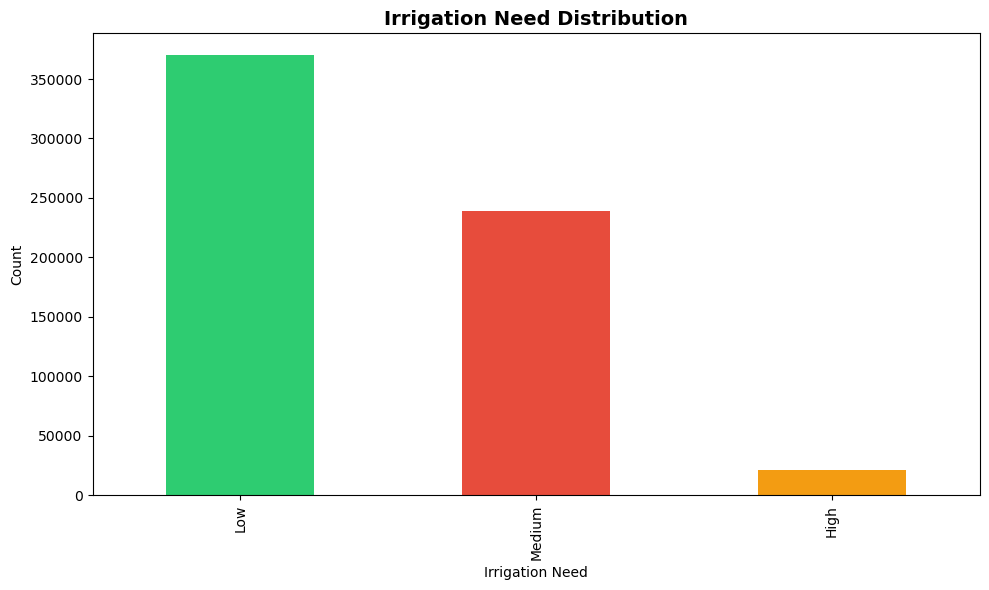

In [10]:
# IRRIGATION_NEED
plt.figure(figsize=(10, 6))
df['Irrigation_Need'].value_counts().plot(kind='bar', color=['#2ecc71', '#e74c3c', '#f39c12'])
plt.title('Irrigation Need Distribution', fontsize=14, fontweight='bold')
plt.ylabel('Count')
plt.xlabel('Irrigation Need')
plt.tight_layout()
plt.show()

<Figure size 1000x600 with 0 Axes>

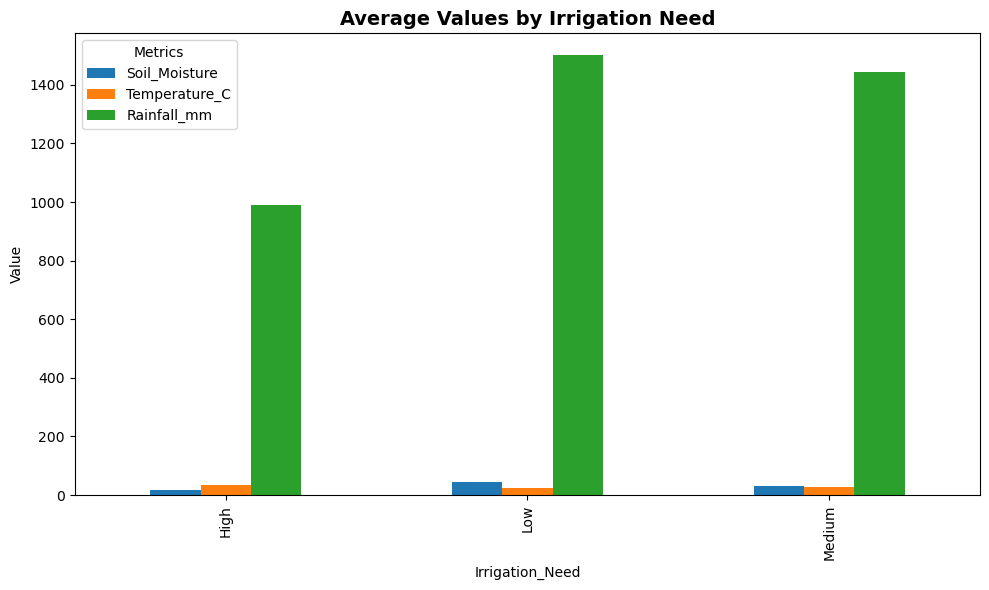

In [11]:
plt.figure(figsize=(10, 6))
avg_data = df.groupby('Irrigation_Need')[['Soil_Moisture', 'Temperature_C', 'Rainfall_mm']].mean()
avg_data.plot(kind='bar', figsize=(10, 6))
plt.title('Average Values by Irrigation Need', fontsize=14, fontweight='bold')
plt.ylabel('Value')
plt.legend(title='Metrics')
plt.tight_layout()
plt.show()

## Feature Engineering

In [12]:
irrigation_mapping = {'Low': 0, 'Medium': 1, 'High': 2}
df['Irrigation_Need'] = df['Irrigation_Need'].map(irrigation_mapping)

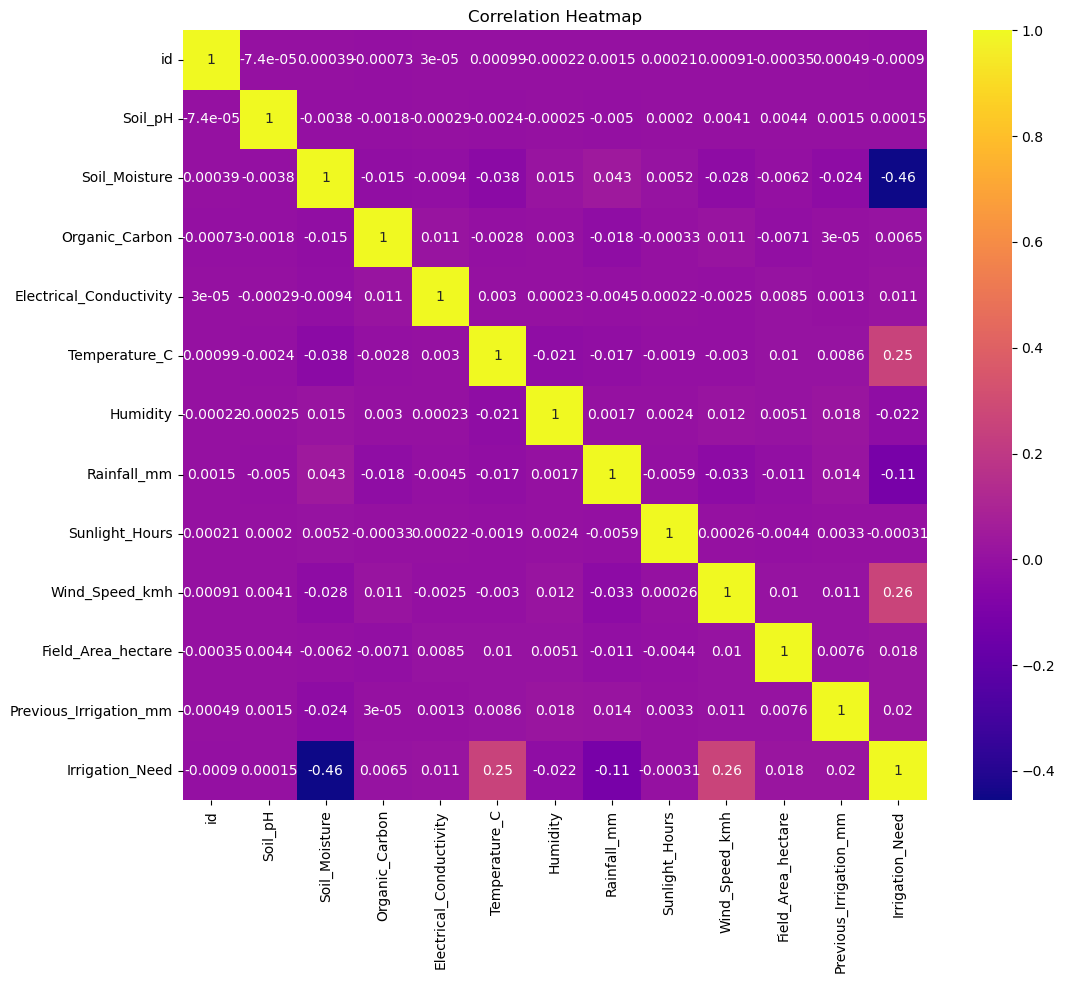

In [13]:
plt.figure(figsize=(12, 10))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='plasma')
plt.title('Correlation Heatmap')
plt.show()

In [14]:
abs(df.corr(numeric_only=True))['Irrigation_Need'].sort_values(ascending=False)

Irrigation_Need            1.000000
Soil_Moisture              0.455482
Wind_Speed_kmh             0.258170
Temperature_C              0.252867
Rainfall_mm                0.111478
Humidity                   0.021870
Previous_Irrigation_mm     0.019637
Field_Area_hectare         0.017699
Electrical_Conductivity    0.010785
Organic_Carbon             0.006451
id                         0.000903
Sunlight_Hours             0.000313
Soil_pH                    0.000150
Name: Irrigation_Need, dtype: float64

In [15]:
df['Moisture_Deficit'] = 65 - df['Soil_Moisture']

df['Evapotranspiration'] = df['Temperature_C'] * (100 - df['Humidity']) / 100

df['Water_Stress'] = df['Moisture_Deficit'] * df['Evapotranspiration'] / 1000

df['Climate_Stress'] = (df['Temperature_C'] * df['Wind_Speed_kmh']) / (df['Rainfall_mm'] + 1)

In [16]:
abs(df.corr(numeric_only=True))['Irrigation_Need'].sort_values(ascending=False)

Irrigation_Need            1.000000
Soil_Moisture              0.455482
Moisture_Deficit           0.455482
Water_Stress               0.389306
Wind_Speed_kmh             0.258170
Temperature_C              0.252867
Climate_Stress             0.149117
Evapotranspiration         0.147342
Rainfall_mm                0.111478
Humidity                   0.021870
Previous_Irrigation_mm     0.019637
Field_Area_hectare         0.017699
Electrical_Conductivity    0.010785
Organic_Carbon             0.006451
id                         0.000903
Sunlight_Hours             0.000313
Soil_pH                    0.000150
Name: Irrigation_Need, dtype: float64

In [17]:
object_cols = df.select_dtypes(include='object').columns

df[object_cols].head(10)

,Soil_Type,Crop_Type,Crop_Growth_Stage,Season,Irrigation_Type,Water_Source,Mulching_Used,Region
0,Loamy,Sugarcane,Sowing,Zaid,Drip,Rainwater,No,East
1,Clay,Wheat,Vegetative,Kharif,Rainfed,River,Yes,South
2,Clay,Rice,Vegetative,Kharif,Sprinkler,Reservoir,Yes,North
3,Sandy,Wheat,Flowering,Kharif,Canal,River,Yes,South
4,Clay,Wheat,Sowing,Rabi,Canal,River,No,South
5,Sandy,Sugarcane,Flowering,Kharif,Sprinkler,River,No,South
6,Silt,Potato,Flowering,Zaid,Sprinkler,Rainwater,No,East
7,Loamy,Rice,Sowing,Zaid,Sprinkler,Reservoir,Yes,East
8,Silt,Potato,Flowering,Kharif,Rainfed,River,Yes,West
9,Silt,Wheat,Vegetative,Kharif,Rainfed,Reservoir,No,Central


In [18]:
df['Mulching_Used'] = df['Mulching_Used'].map({'Yes': 1, 'No': 0})

## Train Test Split

In [19]:
train = df[df['Irrigation_Need'].notna()]
test  = df[df['Irrigation_Need'].isna()]

In [20]:
x = train.drop(['Humidity',
             'Previous_Irrigation_mm',
             'Field_Area_hectare', 
             'Electrical_Conductivity', 
             'Organic_Carbon', 
             'id', 
             'Sunlight_Hours', 
             'Soil_pH',
             'Irrigation_Need'], axis=1)

y = train['Irrigation_Need']

In [21]:
x_final_test = test.drop(['Humidity',
             'Previous_Irrigation_mm',
             'Field_Area_hectare', 
             'Electrical_Conductivity', 
             'Organic_Carbon', 
             'id', 
             'Sunlight_Hours', 
             'Soil_pH',
             'Irrigation_Need'], axis=1)

In [22]:
x_all = pd.concat([x, x_final_test])
x_all = pd.get_dummies(x_all, drop_first=True)

In [23]:
x = x_all.iloc[:len(x)]
x_final_test = x_all.iloc[len(x):]

## Model Training

In [24]:
def algo_test(x, y):
    modeller = [
        BernoulliNB(),
        LogisticRegression(max_iter=500, solver='lbfgs'),   
        DecisionTreeClassifier(),
        RandomForestClassifier(),
        GradientBoostingClassifier(),
        KNeighborsClassifier(),
        AdaBoostClassifier(),
        MultinomialNB(),
        XGBClassifier(use_label_encoder=False, eval_metric='mlogloss', verbosity=0, random_state=42),
        LGBMClassifier(verbose=-1, random_state=42),
        CatBoostClassifier(verbose=0, random_state=42)
    ]
    isimler = [
        "BernoulliNB", 
        "LogisticRegression", 
        "DecisionTreeClassifier", 
        "RandomForestClassifier", 
        "GradientBoostingClassifier", 
        "KNeighborsClassifier", 
        "AdaBoostClassifier", 
        "MultinomialNB",
        "XGBClassifier",
        "LGBMClassifier",
        "CatBoostClassifier"
    ]
    
    x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=.20, random_state=42)
    
    accuracy, precision, recall, f1, mdl = [], [], [], [], []
    
    print("Veriler hazır, modeller deneniyor...")
    for name, model in zip(isimler, modeller):
        print(f"{name} modeli eğitiliyor...")
        try:
            model.fit(x_train, y_train)
            tahmin = model.predict(x_test)
            mdl.append(model)
            accuracy.append(accuracy_score(y_test, tahmin))
            precision.append(precision_score(y_test, tahmin, average="weighted"))
            recall.append(recall_score(y_test, tahmin, average="weighted"))
            f1.append(f1_score(y_test, tahmin, average="weighted"))
        except Exception as e:
            print(f"{name} modeli çalıştırılırken hata oluştu: {e}")
            accuracy.append(np.nan)
            precision.append(np.nan)
            recall.append(np.nan)
            f1.append(np.nan)
            mdl.append(None)
    
    print("Eğitim tamamlandı.")
    
    metrics = pd.DataFrame({
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1": f1,
        "Model": mdl
    }, index=isimler)

    metrics_sorted = metrics.sort_values("F1", ascending=False)
    
    print("\n" + "="*80)
    print("En başarılı model:", metrics_sorted.dropna().iloc[0].name)
    print("="*80)
    
    en_iyi_model = metrics_sorted.dropna().iloc[0]["Model"]

    tahmin = en_iyi_model.predict(x_test)
    print("\nConfusion Matrix:")
    print(confusion_matrix(y_test, tahmin))
    print("\nClassification Report:")
    print(classification_report(y_test, tahmin))

    print("\n" + "="*80)
    print("TÜM MODELLERİN KARŞILAŞTIRMASI")
    print("="*80)
    print(metrics_sorted.drop("Model", axis=1))

    return metrics_sorted.drop("Model", axis=1)

In [ ]:
algo_test(x,y)

Veriler hazır, modeller deneniyor...
BernoulliNB modeli eğitiliyor...
LogisticRegression modeli eğitiliyor...


In [ ]:
best_model= RandomForestClassifier()
best_model.fit(x,y)

In [ ]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=.20, random_state=42)

In [ ]:
pred = best_model.predict(x_test)

In [ ]:
sns.heatmap(confusion_matrix(y_test,pred), annot=True)

In [ ]:
pred_final= best_model.predict(x_final_test)

In [ ]:
submission = pd.DataFrame({
    'id': test['id'],
    'Irrigation_Need': pred_final
})

In [ ]:
submission['Irrigation_Need'] = submission['Irrigation_Need'].map({0.0: 'Low', 
                                                                   1.0: 'Medium', 
                                                                   2.0: 'High'})


In [ ]:
submission.head()

In [ ]:
submission.to_csv("submission.csv", index=False)

In [ ]:
import pickle
import joblib

# ============================================
# 1. PICKLE İLE KAYDET
# ============================================

# Model'i kaydet
with open('model.pkl', 'wb') as f:
    pickle.dump(best_model, f)

# Scaler'ı kaydet
scaler = StandardScaler()
scaler.fit(x_train)  

with open('scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

# Feature names'i kaydet
with open('top_features.pkl', 'wb') as f:
    pickle.dump(top_features, f)

print("✅ Pickle ile kaydedildi")

# ============================================
# 2. JOBLIB İLE KAYDET (Tavsiye edilen)
# ============================================

joblib.dump(best_model, 'model.joblib')
joblib.dump(scaler, 'scaler.joblib')
joblib.dump(top_features, 'top_features.joblib')

print("✅ Joblib ile kaydedildi")